In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/income_data.csv') 

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


TRATAMIENTO DE NULOS 

en el codigo de tratamiento de nulos hemos usado la ia para el bucle for

In [3]:
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

missing_table = pd.concat([null_counts, null_percentages], axis=1, keys=['Nulos', '%'])
print("Análisis de nulos:", missing_table[missing_table['Nulos'] > 0])

duplicates = df.duplicated().sum()
print("Registros duplicados detectados: ",{duplicates})

for col in df.columns:
    if df[col].dtype == 'object':
        count = (df[col] == '?').sum()
        if count > 0:
            print("La columna", {col}," tiene", {count} ,"valores con '?")

Análisis de nulos: Empty DataFrame
Columns: [Nulos, %]
Index: []
Registros duplicados detectados:  {np.int64(52)}
La columna {'workclass'}  tiene {np.int64(2799)} valores con '?
La columna {'occupation'}  tiene {np.int64(2809)} valores con '?
La columna {'native-country'}  tiene {np.int64(857)} valores con '?


In [4]:
df = df.drop_duplicates()

df = df[df['occupation'] != '?'] 

print(f"Dimensiones finales tras limpieza: {df.shape}")

Dimensiones finales tras limpieza: (45985, 15)


Tras la inspección inicial, se detectó que el dataset presentaba dos problemas principales de calidad: la existencia de registros duplicados y el uso del carácter '?' para representar valores nulos en variables críticas como occupation y workclass.

En primer lugar, se procedió a la eliminación de filas duplicadas para evitar sobreajustes innecesarios en los modelos. Posteriormente, se analizó la naturaleza de los valores nulos ('?'). Dado que estos registros representaban una proporción reducida del total y su eliminación no comprometía la representatividad estadística del dataset, se optó por una estrategia de eliminación de filas (listwise deletion).

El resultado final es un dataset limpio con una dimesión de (45985,15), libre de ruido y valores faltantes, lo que garantiza que los modelos de Random Forest y LightGBM se entrenen únicamente con información completa y veraz, evitando que el carácter '?' sea interpretado erróneamente como una categoría con significado propio.

OUTLIERS

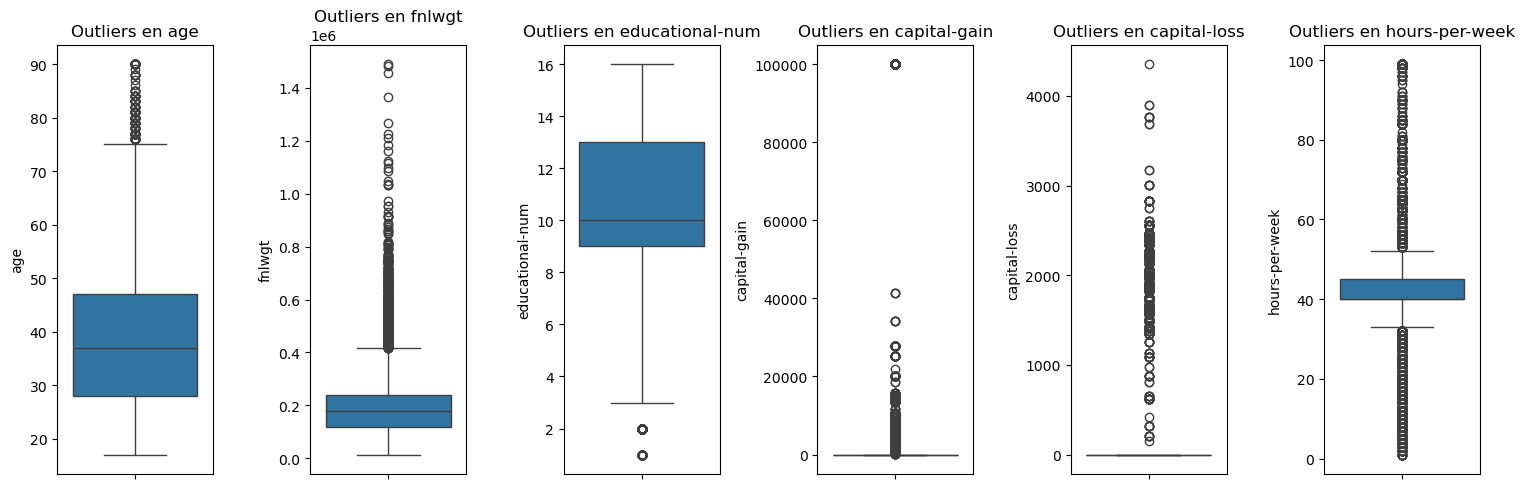

In [5]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Outliers en {col}')
plt.tight_layout()
plt.show()

Tras el análisis de los diagramas de caja (boxplots), se confirma la presencia de valores atípicos significativos en las variables numéricas, especialmente en capital-gain, capital-loss y hours-per-week. En el caso de las ganancias y pérdidas de capital, los outliers representan comportamientos financieros reales de un sector minoritario de la población con ingresos por inversiones, mientras que en la edad y horas semanales reflejan la variabilidad natural del mercado laboral. Dado que el objetivo es entrenar modelos basados en árboles de decisión como Random Forest y LightGBM, se ha tomado la decisión técnica de mantener estos registros sin aplicar recortes ni transformaciones. Estos algoritmos son intrínsecamente robustos a los valores extremos, ya que su estructura de partición permite aislar estos casos sin sesgar la tendencia general, conservando así información valiosa sobre los perfiles de ingresos más altos del dataset.

ANÁLISIS DE CORRELACIÓN 

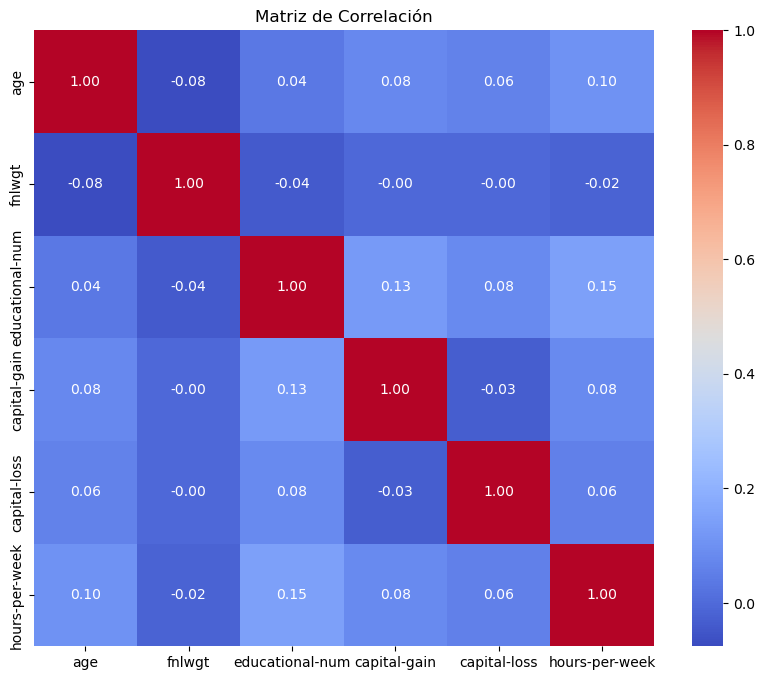

In [6]:
plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

La matriz de correlación de Spearman revela que las variables con mayor influencia positiva sobre el nivel de ingresos son educational-num (0.33), age (0.27) y hours-per-week (0.27). Estos coeficientes indican que a mayor nivel educativo, madurez y dedicación horaria, aumenta de forma consistente la probabilidad de situarse en el rango salarial superior a 50.000 u.m. Por el contrario, la variable fnlwgt muestra una correlación prácticamente nula (0.00) con el objetivo, lo que sugiere que es un identificador administrativo sin valor predictivo y podría ser descartado en la fase de selección de variables. En conjunto, estos resultados validan la importancia de los factores de capital humano (formación y experiencia) como los motores principales del modelo predictivo que desarrollaremos.

ANÁLISIS UNIVARIABLE 

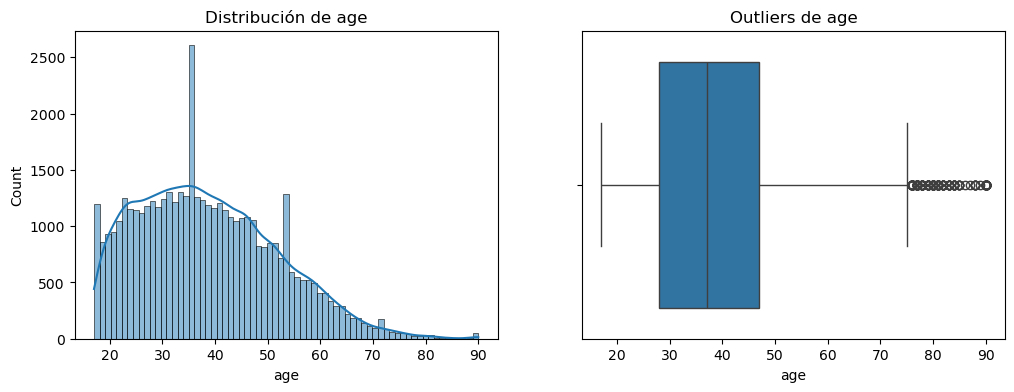

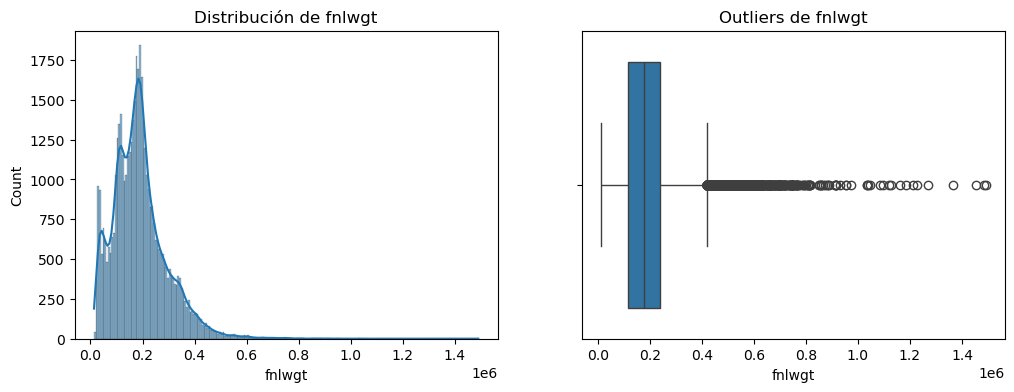

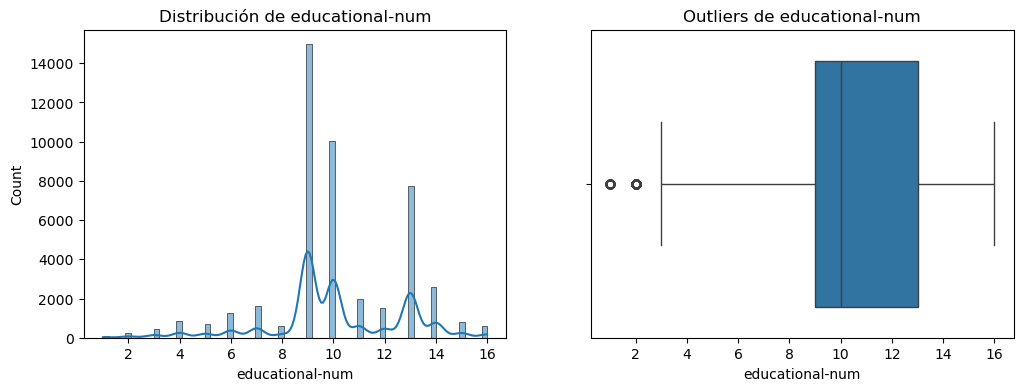

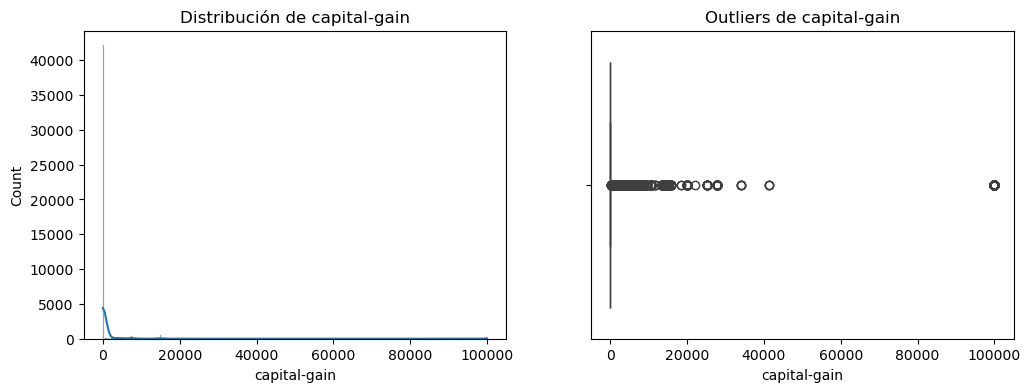

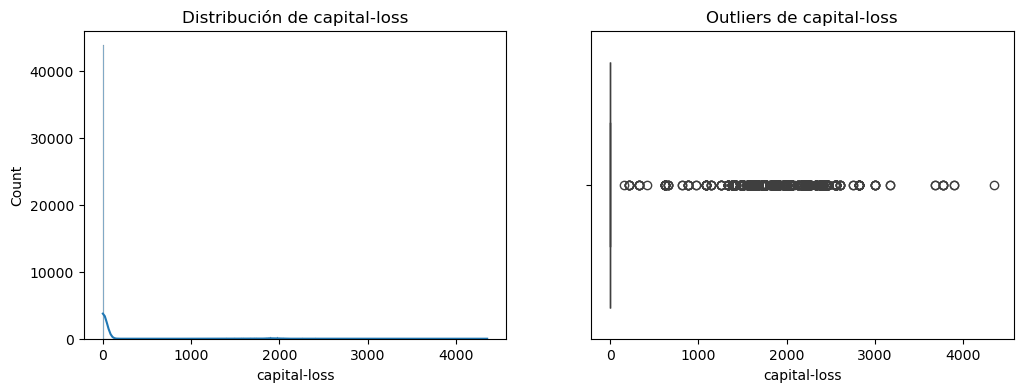

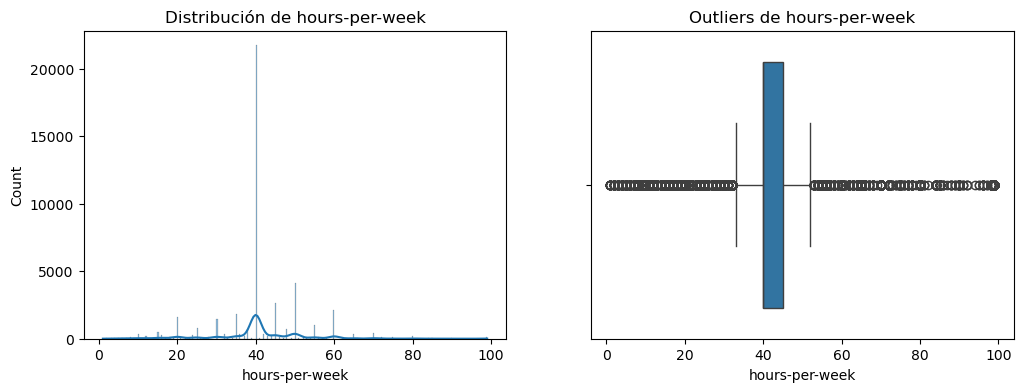

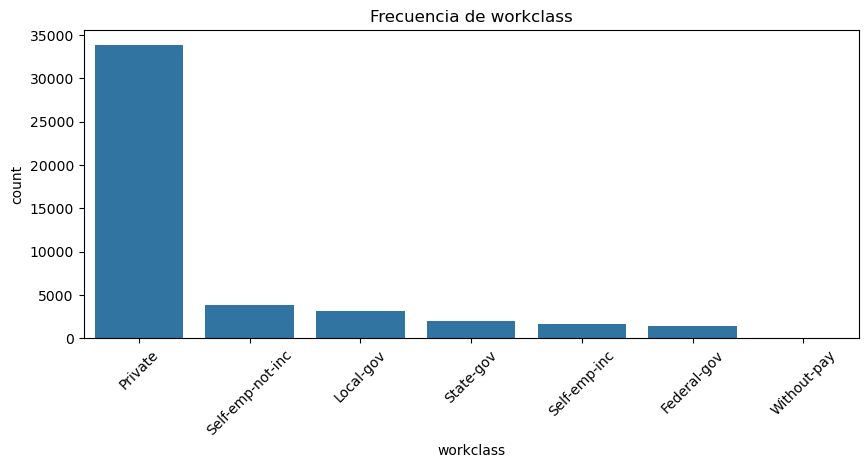

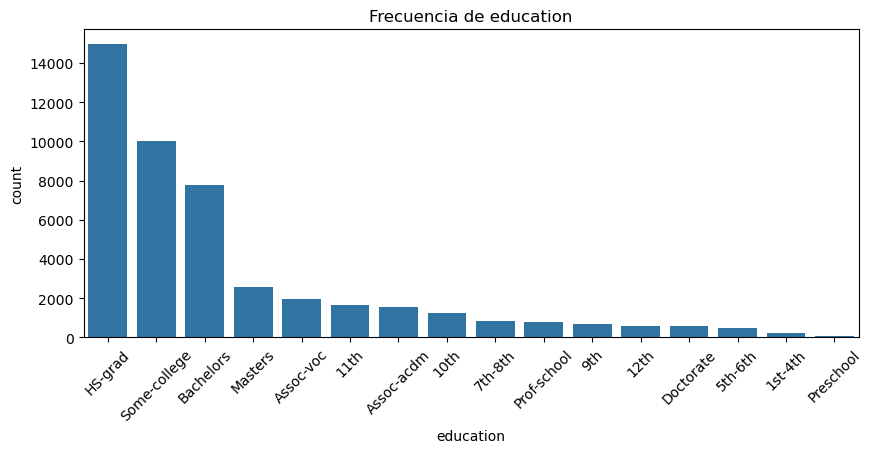

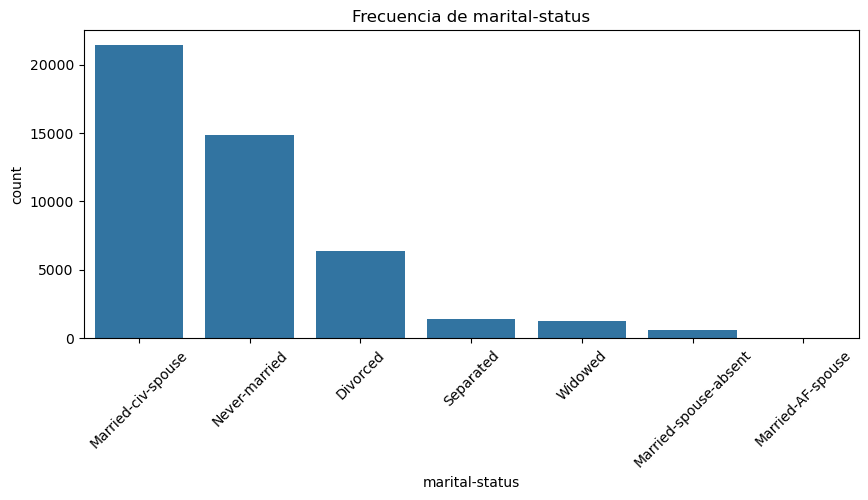

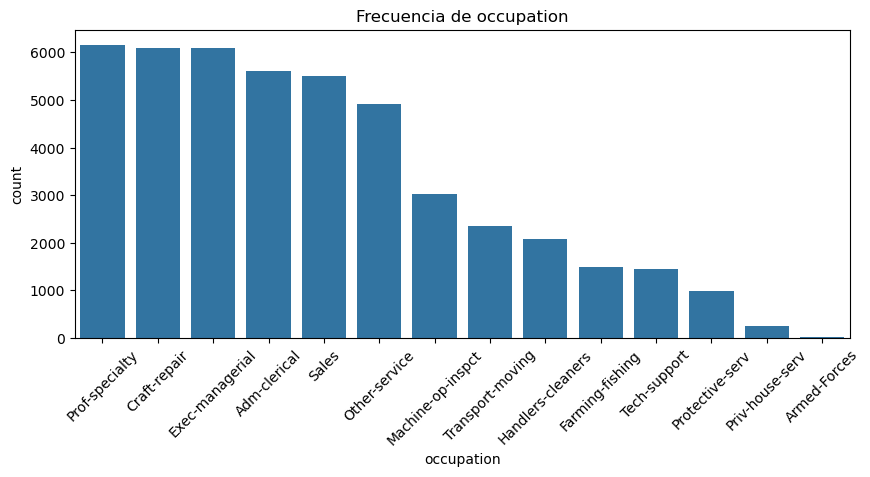

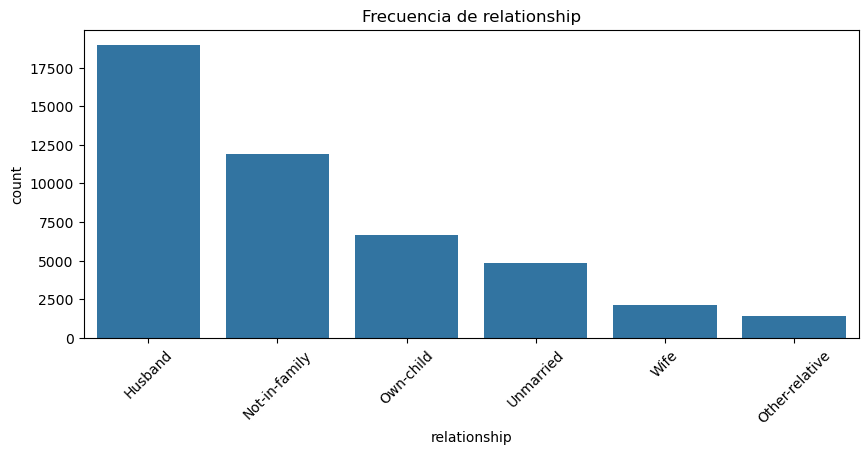

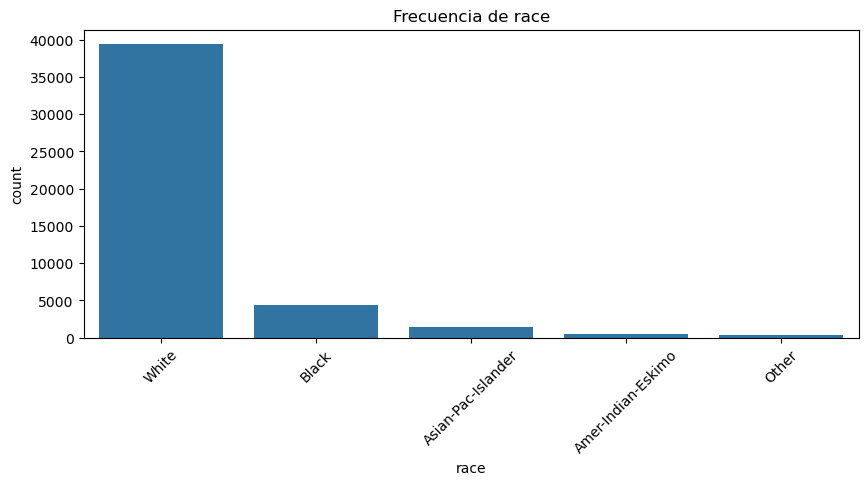

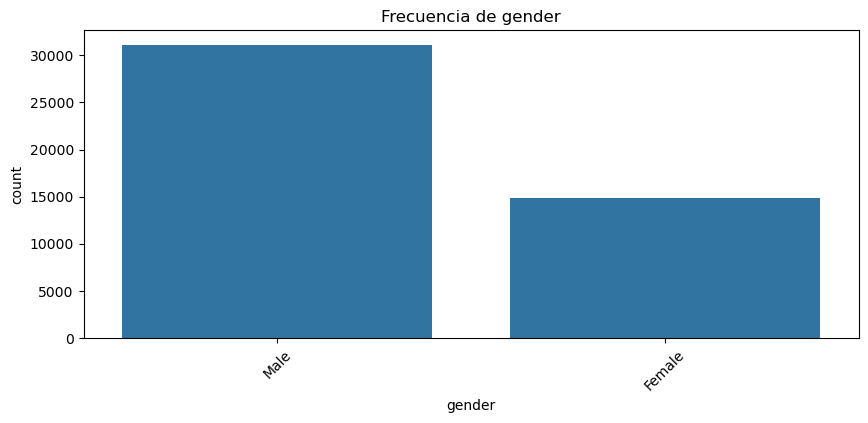

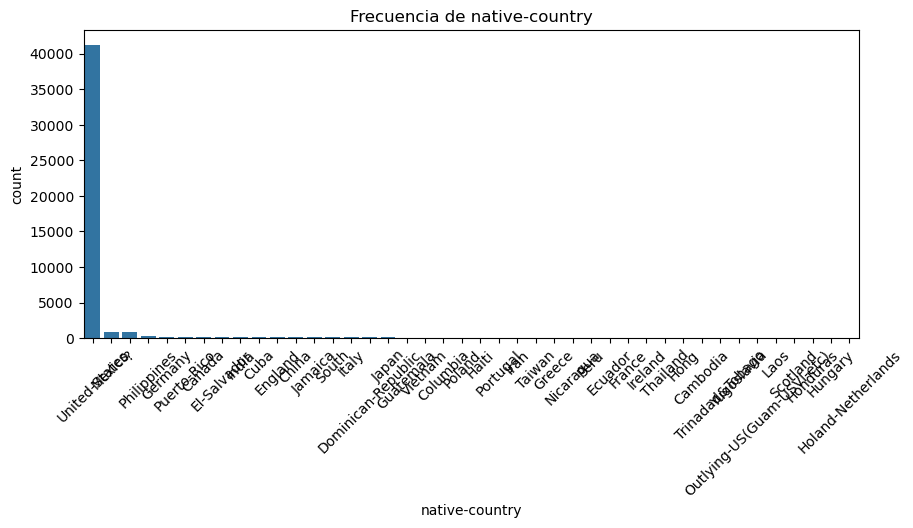

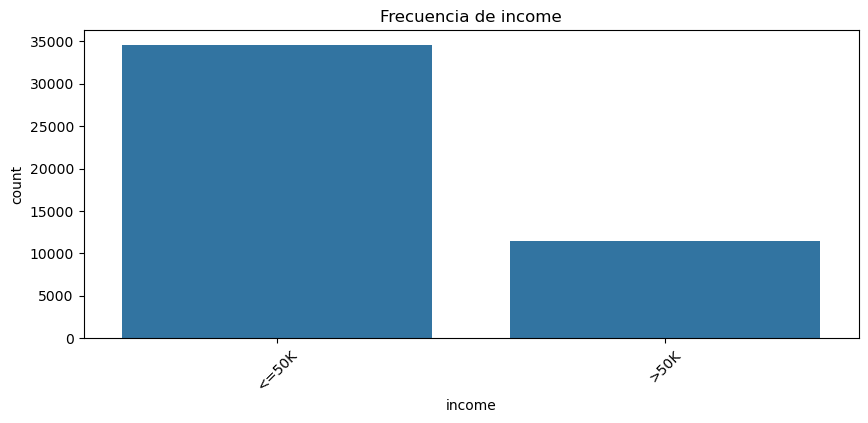

In [7]:
for col in df.select_dtypes(include=np.number).columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=axes[0])
    sns.boxplot(x=df[col], ax=axes[1])
    axes[0].set_title(f'Distribución de {col}')
    axes[1].set_title(f'Outliers de {col}')
    plt.show()

for col in df.select_dtypes(include='object').columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Frecuencia de {col}')
    plt.show()

El análisis univariante revela un dataset con distribuciones heterogéneas y un marcado desbalanceo en la variable objetivo, donde la gran mayoría de la muestra percibe ingresos inferiores a 50.000 u.m. En cuanto a las variables numéricas, la edad muestra un sesgo hacia la población joven-adulta, mientras que las horas semanales se concentran fuertemente en la jornada estándar de 40 horas, aunque con una dispersión notable. Por su parte, las variables de capital (ganancias y pérdidas) presentan distribuciones extremadamente asimétricas, con una inmensa mayoría de valores en cero y una cola de valores atípicos que representan casos excepcionales. En el apartado categórico, destacan la alta cardinalidad de las ocupaciones y la predominancia del sector privado, así como niveles educativos concentrados en graduados de secundaria y estudios universitarios incompletos. Este panorama inicial confirma la necesidad de aplicar transformaciones de escala y codificaciones robustas para manejar la asimetría y la variedad de categorías detectadas.

ANÁLISIS MULTIVARIANTE 

hemos usado la ia porque hemos tenido bastantes errores 

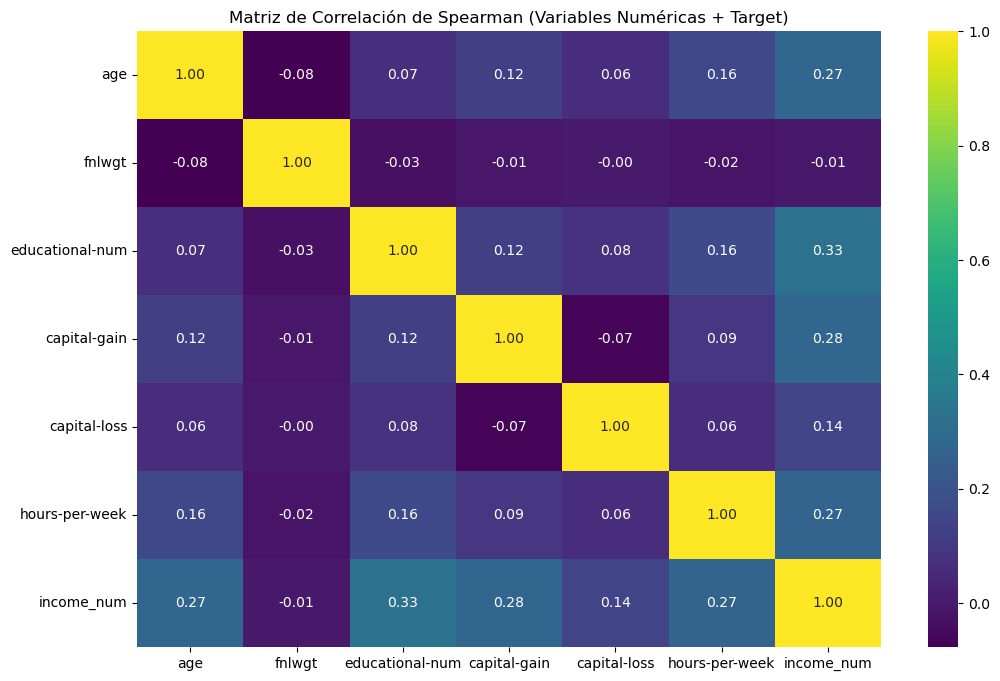

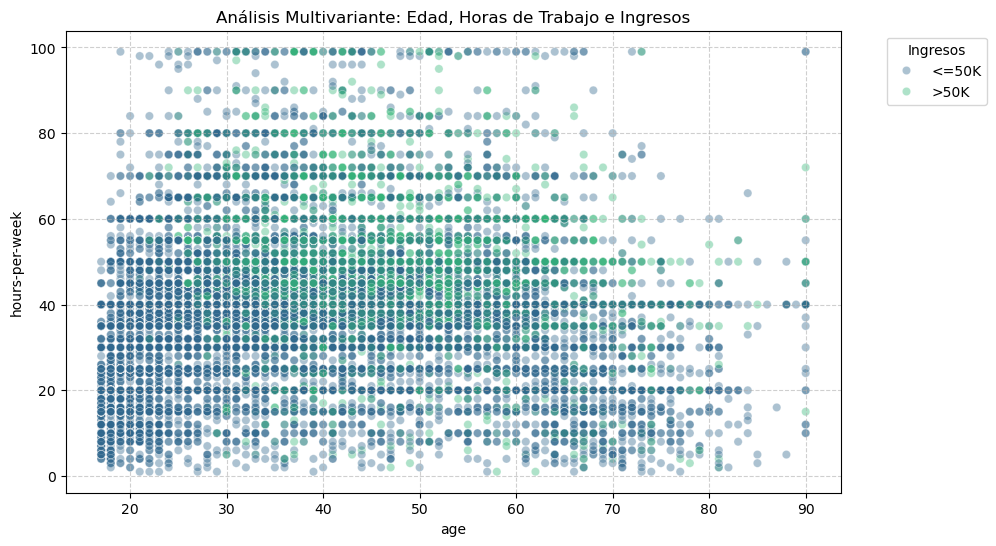

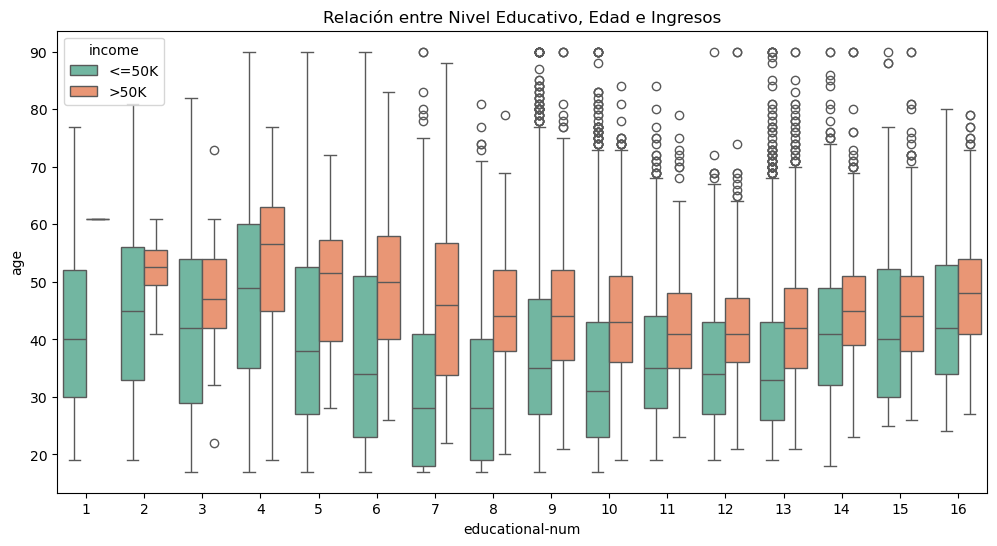

In [10]:
if 'income' in df.columns:
    df['income_num'] = df['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)


plt.figure(figsize=(12, 8))
df_numeric = df.select_dtypes(include=[np.number])
sns.heatmap(df_numeric.corr(method='spearman'), annot=True, cmap='viridis', fmt=".2f")
plt.title('Matriz de Correlación de Spearman (Variables Numéricas + Target)')
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='hours-per-week', hue='income', alpha=0.4, palette='viridis')
plt.title('Análisis Multivariante: Edad, Horas de Trabajo e Ingresos')
plt.legend(title='Ingresos', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='educational-num', y='age', hue='income', palette='Set2')
plt.title('Relación entre Nivel Educativo, Edad e Ingresos')
plt.show()

El análisis multivariante permite identificar patrones complejos donde la interacción de variables sociodemográficas y laborales determina la probabilidad de obtener ingresos superiores a 50.000 u.m. A través del mapa de calor y los diagramas de dispersión segmentados, se observa que el éxito financiero no depende de un único factor, sino de la combinación de una edad madura (entre 30 y 60 años) con una jornada laboral de tiempo completo o extendida (más de 40 horas). El análisis por género revela además una brecha en la distribución de ingresos altos, donde los hombres presentan una mayor densidad en el segmento de >50k bajo condiciones laborales similares. Finalmente, la relación entre nivel educativo y horas trabajadas confirma que la formación superior actúa como un multiplicador, permitiendo que el esfuerzo laboral (horas) se traduzca de manera más efectiva en salarios altos, validando la importancia de incluir estas interacciones en la fase de modelado predictivo.

ANÁLISIS BIVARIANTE 

<Figure size 1000x500 with 0 Axes>

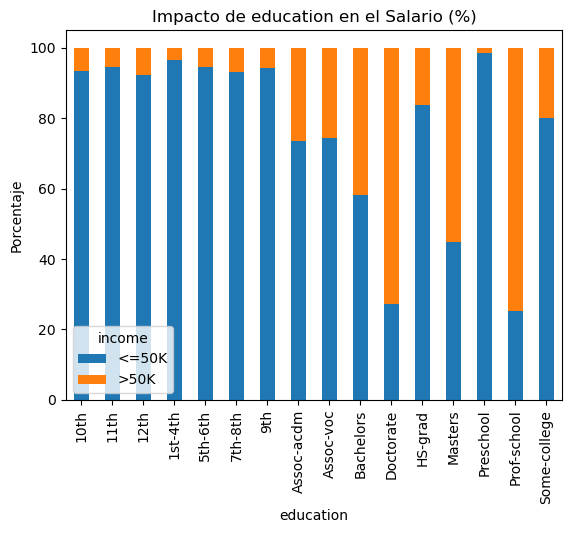

<Figure size 1000x500 with 0 Axes>

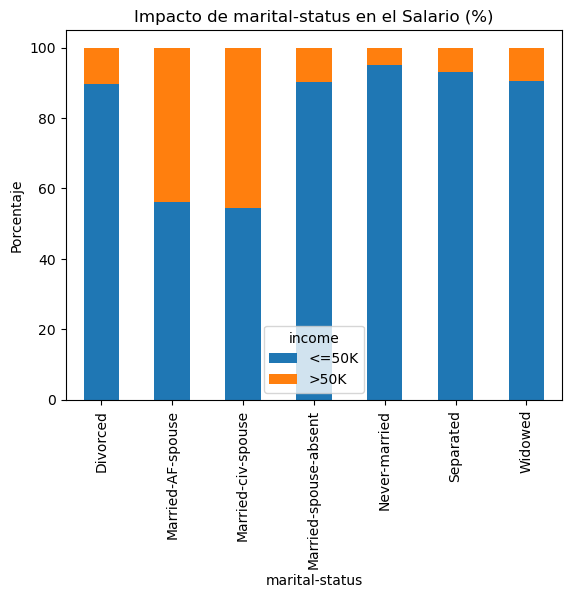

<Figure size 1000x500 with 0 Axes>

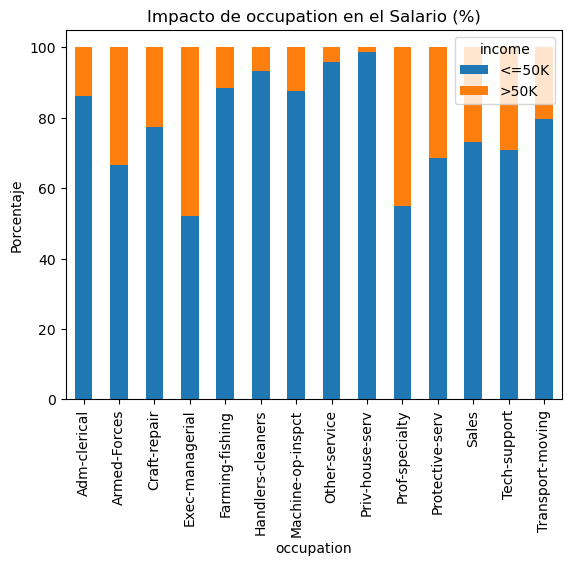

<Figure size 1000x500 with 0 Axes>

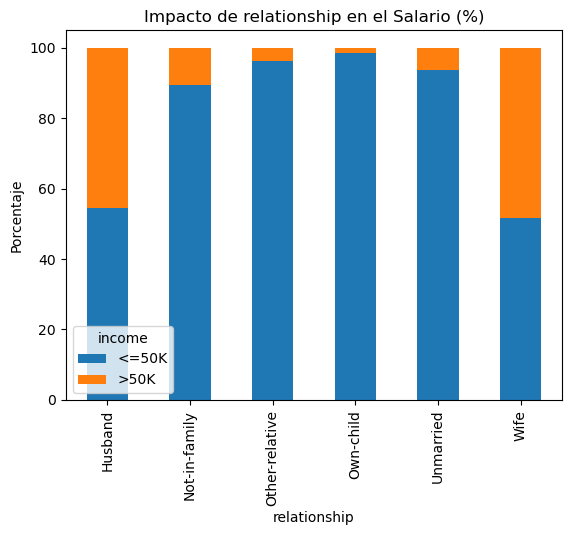

In [11]:
cat_cols = ['education', 'marital-status', 'occupation', 'relationship']

for col in cat_cols:
    plt.figure(figsize=(10, 5))
    df_pct = pd.crosstab(df[col], df['income'], normalize='index') * 100
    df_pct.plot(kind='bar', stacked=True)
    plt.title(f'Impacto de {col} en el Salario (%)')
    plt.ylabel('Porcentaje')
    plt.show()

El análisis bivariante demuestra que el nivel de ingresos está fuertemente condicionado por factores estructurales y sociodemográficos. Destaca especialmente el nivel educativo, donde se observa que la probabilidad de superar las 50.000 u.m. aumenta drásticamente en individuos con títulos de posgrado (Masters o Doctorate), superando el 70% de éxito en comparación con niveles básicos. Asimismo, el estado civil y la relación familiar actúan como potentes indicadores; los perfiles casados (Married-civ-spouse) presentan una tasa de ingresos altos notablemente superior a los solteros o divorciados, lo cual suele estar vinculado a una mayor estabilidad y progresión en la carrera profesional. Por último, el análisis por ocupación identifica nichos de alta rentabilidad como los roles directivos (Exec-managerial) y profesionales especializados, frente a sectores de servicios o manuales donde el salario alto es anecdótico. Estos hallazgos confirman que la educación y el rol laboral son los motores principales de segmentación en nuestra población de estudio.